[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PooryaBehnamie/bioimage-analysis-notebooks/blob/main/Notebook_3_From_Gaussian_to_UNet.ipynb)

#  Notebook 3: From Gaussian Blobs to UNet

## Classical & Deep Learning for Bioimage Analysis

In this notebook, we'll build on our foundation of image handling to perform robust object detection. We will connect the physics of microscopy to the algorithms we choose, learn to clean up our images, and apply powerful filtering techniques. Finally, we'll get a high-level introduction to the world of deep learning for bioimage analysis.

Think of it as a story:
1) **Light** excites fluorophores → they glow → the camera records a *blur* of each glow.  
2) We shape this blur with **Gaussian filters**, remove haze with a **rolling ball**, and tidy masks with **morphology**.  
3) We detect spots with **LoG**, and when things get complicated, we invite **CNNs & U-Net** to help, and actually train one.  
4) We judge fairly with **metrics** (Dice, IoU, Precision, Recall, F1) using **Ground Truth**.  
5) We finish with tools you can use today and a peek at where the field is going.

### Setup
All packages are listed in the repository README. On Google Colab everything needed (including PyTorch) is pre-installed. The deep-learning part trains a very small model on the **CPU in a few minutes**; no GPU needed.

In [1]:
# --- Setup: works locally and on Google Colab ---
import sys
from pathlib import Path

if "google.colab" in sys.modules and not Path("data").exists():
    # On Colab, fetch the repository so the example data is available
    !git clone -q https://github.com/PooryaBehnamie/bioimage-analysis-notebooks.git
    %cd bioimage-analysis-notebooks

DATA_DIR = Path("data")                      # example images shipped with the repo
OUT_DIR = Path("outputs"); OUT_DIR.mkdir(exist_ok=True)   # anything we save goes here (git-ignored)

import matplotlib
matplotlib.rcParams["figure.dpi"] = 72       # keeps saved notebooks small; raise for sharper figures

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
import pandas as pd

from skimage import io, color, measure, img_as_float, img_as_ubyte
from skimage.filters import gaussian, threshold_otsu
from skimage.morphology import disk, opening, closing, erosion, dilation, white_tophat
from skimage.restoration import rolling_ball
from skimage.feature import blob_log, peak_local_max
from skimage.segmentation import watershed
from scipy import ndimage as ndi
from scipy.special import j1
from scipy.optimize import linear_sum_assignment, curve_fit

# Reproducibility: every random number in this notebook comes from these seeds
SEED = 0
rng = np.random.default_rng(SEED)

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['image.cmap'] = 'gray'
print("All libraries imported successfully!")

All libraries imported successfully!


### A Tiny Recap

So far, we've learned:
1.  **The 'Why'**: We started with a high-level overview of different imaging modalities in biology and medicine and established why automated image analysis is crucial. We chose ecDNA in FISH images as our guiding biological problem.
2.  **The 'What'**: In the second notebook, we treated images as what they are to a computer: NumPy arrays. We explored different libraries (scikit-image, OpenCV, Matplotlib) for I/O, understood the importance of data types, and learned to manipulate images by changing color spaces and applying masks. We ended with our first taste of object detection using connected components analysis.

Now, we will bridge the gap between the physics of how images are formed and the algorithms we use to detect objects within them.

## Part 1: How We Get the Image (Microscopy 101)

#### 1.1 The Magic of Fluorescence Microscopy
In fluorescence microscopy, we make specific parts of a biological sample glow. We do this by labeling them with special molecules called fluorophores.

Here is the basic idea:
* **Excitation**: We shine a specific color (wavelength) of light onto the sample. This light usually comes from a powerful lamp or a laser.
* **Energy Absorption**: A fluorophore molecule absorbs the energy from this light, and its electrons jump to a higher energy state.
* **Emission**: This higher energy state is unstable. Almost immediately (within nanoseconds), the electron falls back to its normal state. As it falls, it releases the extra energy as a new particle of light (a photon).
* **Stokes Shift**: The emitted light has a longer wavelength (lower energy) than the light used for excitation. For example, we might excite a Green Fluorescent Protein (GFP) molecule with blue light (wavelength ~488 nm), and it will emit green light (wavelength ~507 nm). This change in wavelength is called the Stokes shift. (Exact peaks vary slightly between GFP variants.)

Because the sample itself is producing light, we see bright, glowing signals on a very dark background. This gives us excellent contrast and allows us to see our targets with high specificity, sometimes even down to a single molecule.


*The spectra are plotted in the next cell.*

#### How the Microscope Captures the Light

Fluorescence microscopes use **filter cubes** to separate excitation and emission:

1.  **Excitation Filter**: Only allows the chosen excitation wavelength to hit the sample.
2.  **Dichroic Mirror**: Reflects excitation light toward the sample, but lets emission light pass through.
3.  **Emission Filter**: Cleans up remaining excitation light, so only the emitted photons reach the detector (camera).

The result is a clean, high-contrast image where only labeled structures are visible. For a clear diagram of this light path, see the [fluorescence microscope article on Wikipedia](https://en.wikipedia.org/wiki/Fluorescence_microscope) or Nikon's [MicroscopyU introduction to fluorescence](https://www.microscopyu.com/techniques/fluorescence/introduction-to-fluorescence-microscopy).

> 📌 **Think of it as a nightclub:** the DJ (excitation light) shines a UV spotlight, people with fluorescent shirts (fluorophores) glow, and the bouncer (filters) only lets the glow enter your camera’s eye.

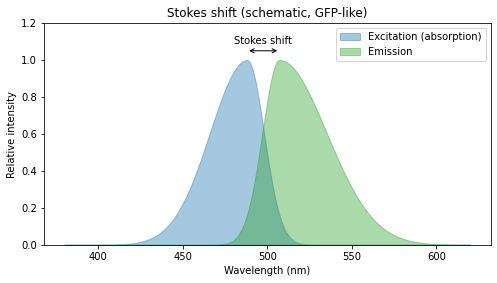

In [2]:
# Illustrative excitation/emission spectra of a GFP-like fluorophore (shapes are schematic, peaks realistic)
wl = np.linspace(380, 620, 500)
def band(x, peak, left, right):
    """Asymmetric bell curve: different widths on each side of the peak."""
    w = np.where(x < peak, left, right)
    return np.exp(-0.5 * ((x - peak) / w) ** 2)

excitation = band(wl, 488, 22, 10)
emission   = band(wl, 507, 10, 28)

plt.figure(figsize=(8, 4))
plt.fill_between(wl, excitation, alpha=0.4, color="tab:blue", label="Excitation (absorption)")
plt.fill_between(wl, emission, alpha=0.4, color="tab:green", label="Emission")
plt.annotate("", xy=(507, 1.05), xytext=(488, 1.05), arrowprops=dict(arrowstyle="<->"))
plt.text(497.5, 1.09, "Stokes shift", ha="center")
plt.xlabel("Wavelength (nm)"); plt.ylabel("Relative intensity"); plt.ylim(0, 1.2)
plt.title("Stokes shift (schematic, GFP-like)"); plt.legend(loc="upper right")
plt.show()
# Real, measured spectra for thousands of fluorophores: https://www.fpbase.org

#### 1.2 A Practical Example: FISH for ecDNA
A powerful application of this technology is Fluorescence In Situ Hybridization (FISH). FISH is a technique used to label and see specific DNA or RNA sequences directly inside cells.

Here’s how a FISH experiment works:
1.  A short piece of DNA, called a **probe**, is created in the lab. This probe is designed to be complementary to the DNA sequence you want to find (e.g., a specific gene).
2.  This probe is tagged with fluorophore molecules.
3.  The probe is applied to the cells. It travels into the nucleus and binds (hybridizes) to its target DNA sequence.
4.  After washing away any unbound probes, the sample is viewed under the fluorescence microscope.

You will see bright, fluorescent spots wherever the probe has bound. For example, if you are studying **extrachromosomal DNA (ecDNA)**, which are small circles of DNA that can carry cancer-causing genes, a FISH experiment will show these ecDNA as small, bright dots inside the cell's nucleus. Each dot, or **focus**, represents one or more ecDNA circles glowing brightly because they are covered in fluorescent probes.

#### 1.3 The Physics of Seeing: Why a Point Becomes a Blob
Even with a perfect microscope, a tiny point of light, like a single fluorophore, will never appear as a perfect, sharp point in the final image. Instead, it will look like a small, blurry spot. This blurring is not a mistake; it is a fundamental limit caused by the wave-like nature of light. This phenomenon is called **diffraction**.

#### Airy Disk & Point Spread Function (PSF):

**The Point Spread Function (PSF)**
When light waves from a point source pass through the circular lens of the microscope, they spread out and interfere with each other, creating a pattern of a bright central disk surrounded by dimmer rings. This entire pattern is called an **Airy pattern**, and the central bright spot is the Airy disk.

The **Point Spread Function (PSF)** is the name we give to this 3D blurry shape that the microscope produces from a single point source. You can think of the PSF as the microscope's "fingerprint." Every single point of light in your sample gets "stamped" with this same blurry shape in the final image.

The size of the Airy disk sets the diffraction limit of resolution. For a typical high-quality microscope using visible light, this limit is about **200 nanometers (nm)**. Any two objects closer than 200 nm will blur together into a single spot.


#### Resolution Limit:

The Airy disk's radius sets the **diffraction limit**:

$$ r = \frac{0.61 \lambda}{NA} $$

where $\lambda$ is the wavelength of light and $NA$ is the numerical aperture of the lens. For visible light, the resolution is typically around **~200 nm**.

#### Gaussian Approximation:

**The Gaussian Approximation**
In real images, the rings of the Airy pattern are very dim and often not visible. The central blob of light looks very much like a 2D **Gaussian function**, which describes the familiar "bell curve" shape. A 2D Gaussian function is described by the formula:

$$G(x,y) = A \cdot \exp\left(-\frac{(x-x_0)^2 + (y-y_0)^2}{2\sigma^2}\right)$$

where $(x_0, y_0)$ is the center of the spot, $A$ is the peak intensity, and $\sigma$ (sigma) is the standard deviation, which controls the width or "blurriness" of the spot.

Because the Gaussian shape is mathematically simpler than the full Airy pattern, we often approximate the PSF as a Gaussian blob for image analysis. This is a very useful simplification for algorithms that need to find the exact center of a spot. This brings us to our first object detection baseline: **Gaussian Blur**.

The next cell computes the Airy pattern and shows how well a Gaussian approximates it.

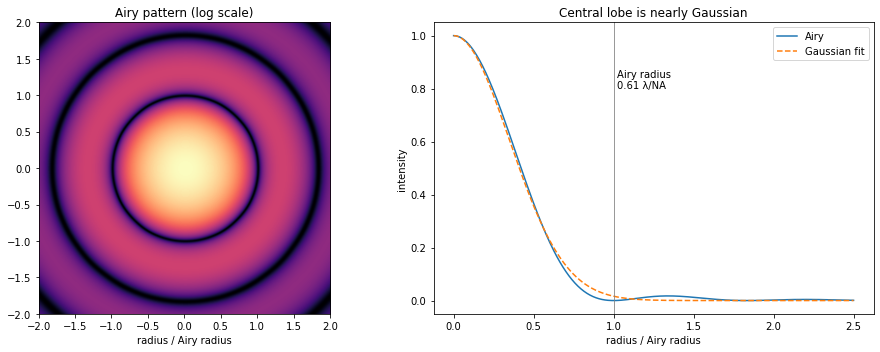

Best-fit Gaussian sigma ≈ 0.21 λ/NA
Example: λ=520 nm, NA=1.4 -> Airy radius = 227 nm


In [3]:
def airy(v):
    """Airy intensity pattern I(v) = (2*J1(v)/v)^2, with v the scaled radial coordinate."""
    v = np.where(v == 0, 1e-12, v)
    return (2 * j1(v) / v) ** 2

V0 = 3.8317                      # first zero of J1: the edge of the Airy disk (radius 0.61*lambda/NA)
n = 301
y, x = np.mgrid[-n//2:n//2+1, -n//2:n//2+1] * (4 * V0 / n)
airy_img = airy(np.hypot(x, y))

# Fit a Gaussian to the central lobe
r = np.linspace(0, 2.5 * V0, 400)
gauss = lambda rr, s: np.exp(-rr**2 / (2 * s**2))
central = r < V0
(sigma_fit,), _ = curve_fit(gauss, r[central], airy(r[central]), p0=[1.0])

fig, axs = plt.subplots(1, 2, figsize=(13, 5))
axs[0].imshow(np.log10(airy_img + 1e-4), cmap="magma", extent=[-2, 2, -2, 2])
axs[0].set_title("Airy pattern (log scale)"); axs[0].set_xlabel("radius / Airy radius")
axs[1].plot(r / V0, airy(r), label="Airy")
axs[1].plot(r / V0, gauss(r, sigma_fit), "--", label="Gaussian fit")
axs[1].axvline(1, color="gray", lw=0.8); axs[1].text(1.02, 0.8, "Airy radius\n0.61 λ/NA")
axs[1].set_xlabel("radius / Airy radius"); axs[1].set_ylabel("intensity"); axs[1].legend()
axs[1].set_title("Central lobe is nearly Gaussian")
plt.tight_layout(); plt.show()

print(f"Best-fit Gaussian sigma ≈ {sigma_fit / V0 * 0.61:.2f} λ/NA")
lam, NA = 520, 1.4        # green emission, oil-immersion objective
print(f"Example: λ={lam} nm, NA={NA} -> Airy radius = {0.61*lam/NA:.0f} nm")

#### The Rayleigh criterion
Two point sources are just "resolved" when the center of one Airy pattern falls on the first dark ring of the other, i.e. when they are one Airy radius apart. Closer than that, the two blobs merge into one. This is exactly the problem of **touching ecDNA spots** you saw in Notebook 2.

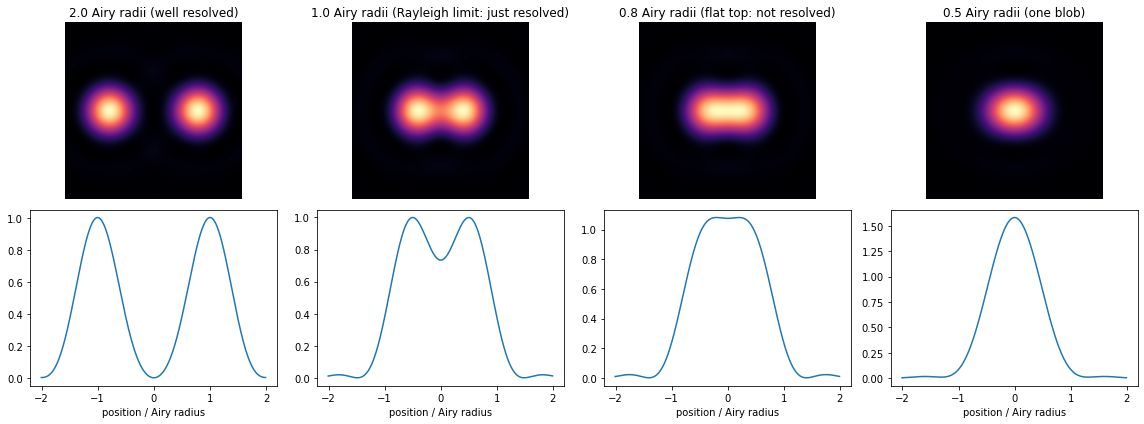

In [4]:
seps = [2.0, 1.0, 0.8, 0.5]                     # separation in units of the Airy radius
labels = ["well resolved", "Rayleigh limit: just resolved", "flat top: not resolved", "one blob"]
fig, axs = plt.subplots(2, 4, figsize=(16, 6))
for k, (s, lab) in enumerate(zip(seps, labels)):
    dx = s * V0 / 2
    img = airy(np.hypot(x - dx, y)) + airy(np.hypot(x + dx, y))
    axs[0, k].imshow(img, cmap="magma", extent=[-2, 2, -2, 2]); axs[0, k].set_title(f"{s} Airy radii ({lab})")
    axs[0, k].axis("off")
    axs[1, k].plot(x[n//2] / V0, img[n//2]); axs[1, k].set_xlabel("position / Airy radius")
plt.tight_layout(); plt.show()

## Part 2: Object Detection with Gaussian Blur and Background Subtraction

### 2.1 Images as Functions & Convolutions
A digital image is just a matrix of numbers where each pixel has an intensity value.

To process images, we apply **filters** (also called **kernels**). A kernel is a small matrix that we slide across the image, performing a weighted sum at each position. This sliding operation is called **convolution**.

> 📌 **Examples:**
> - A **blur** filter averages neighboring pixel values.
> - A **sharpen** filter emphasizes differences between neighbors.
> - An **edge detection** filter (like Sobel or Laplacian) highlights areas of rapid intensity change.

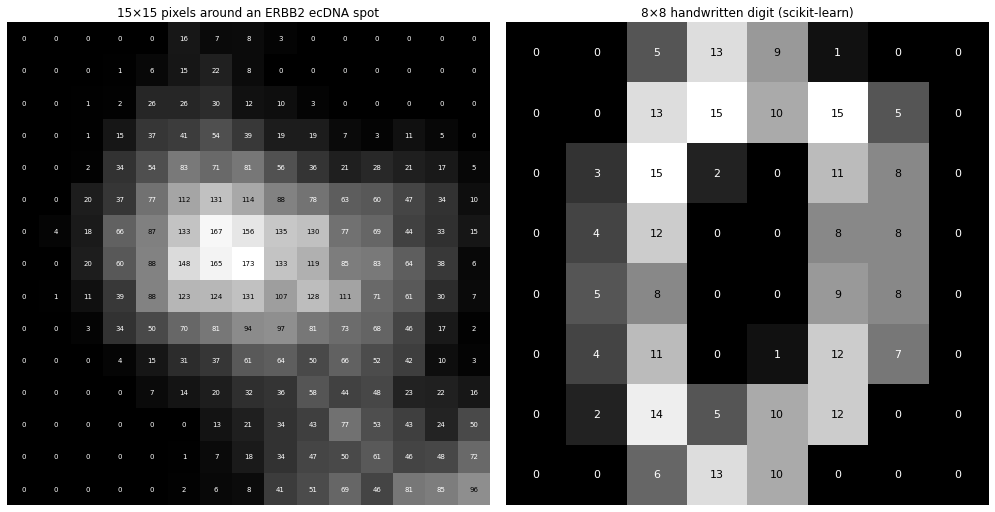

In [5]:
# What the computer "sees": pixel values around one ecDNA spot in our FISH image
rgb_fish = io.imread(DATA_DIR / "fish_rgb.tif").astype(np.int16)
red_probe = np.clip(rgb_fish[..., 0] - rgb_fish[..., 2], 0, 255).astype(np.uint8)

# pick a clearly visible but not saturated spot inside our usual zoom window
peaks = peak_local_max(red_probe[700:1100, 1250:1650], min_distance=8, threshold_abs=100)
vals = red_probe[700:1100, 1250:1650][tuple(peaks.T)]
cy, cx = peaks[np.argmin(np.abs(vals.astype(int) - 170))] + [700, 1250]
patch = red_probe[cy-7:cy+8, cx-7:cx+8]

from sklearn.datasets import load_digits
digit = load_digits().images[0]                     # an 8x8 handwritten digit (values 0-16)

fig, axs = plt.subplots(1, 2, figsize=(14, 7))
for ax, arr, title, fs in [(axs[0], patch, "15×15 pixels around an ERBB2 ecDNA spot", 7),
                           (axs[1], digit, "8×8 handwritten digit (scikit-learn)", 11)]:
    ax.imshow(arr, cmap="gray")
    for (i, j), val in np.ndenumerate(arr):
        ax.text(j, i, int(val), ha="center", va="center", fontsize=fs,
                color="black" if val > arr.max() / 2 else "white")
    ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.show()

Notice that the ecDNA spot is not a sharp point but a smooth hill of values that rises to a peak and falls off. That is the **PSF** from Part 1, captured in real data.

### 2.2 Gaussian Blur & Gaussian Fitting

Since our objects of interest (ecDNA foci) are physically blurred into Gaussian-like shapes, we can use a Gaussian filter as a matched filter to find them. The idea is to convolve our image with a Gaussian kernel that has a similar size ($\sigma$) to the objects we want to detect. This will make the objects we are looking for even brighter while smoothing out noise and features of other sizes. After blurring, a simple threshold can often segment the objects.

Because microscope spots resemble Gaussian blobs, Gaussian filters are particularly useful:

- **Gaussian Blur**: Smooths noise while preserving the general shape of blobs. The kernel weights follow a Gaussian function, giving the highest weight to the center pixel.
- **Gaussian Fitting**: After detecting a blob, we can fit a Gaussian model to its pixel values to find its precise center (sub-pixel localization).



**Why blur before detection?**
1. It removes high-frequency noise (tiny, random spikes in intensity).
2. It makes real spots more uniformly "Gaussian-like," improving the performance of blob detectors.
3. It helps create a cleaner result after applying a threshold.

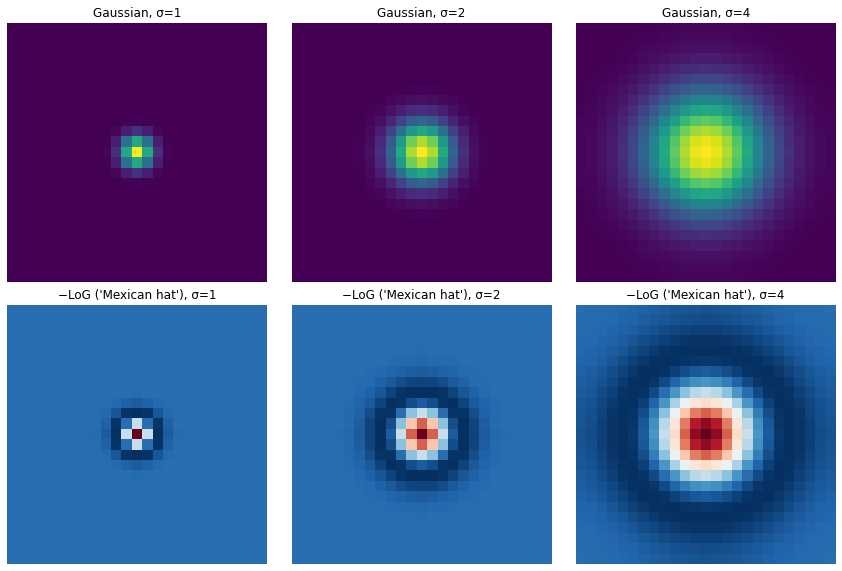

In [6]:
# Gaussian kernels (top) and Laplacian-of-Gaussian kernels (bottom) at increasing sigma
from scipy.ndimage import gaussian_laplace
sigmas = [1, 2, 4]
size = 25
impulse = np.zeros((size, size)); impulse[size//2, size//2] = 1

fig, axs = plt.subplots(2, 3, figsize=(12, 8))
for k, s in enumerate(sigmas):
    axs[0, k].imshow(ndi.gaussian_filter(impulse, s), cmap="viridis"); axs[0, k].set_title(f"Gaussian, σ={s}")
    axs[1, k].imshow(-gaussian_laplace(impulse, s), cmap="RdBu_r");   axs[1, k].set_title(f"−LoG ('Mexican hat'), σ={s}")
for ax in axs.ravel(): ax.axis("off")
plt.tight_layout(); plt.show()

### 2.3 Code Demo: Gaussian Blur for Microscopy Images
Here’s a simple Python demo using OpenCV and Matplotlib. We will:
1. Create a small synthetic FISH-like RGB image and convert it to grayscale.
2. Apply a Gaussian blur.
3. Display the results side-by-side.

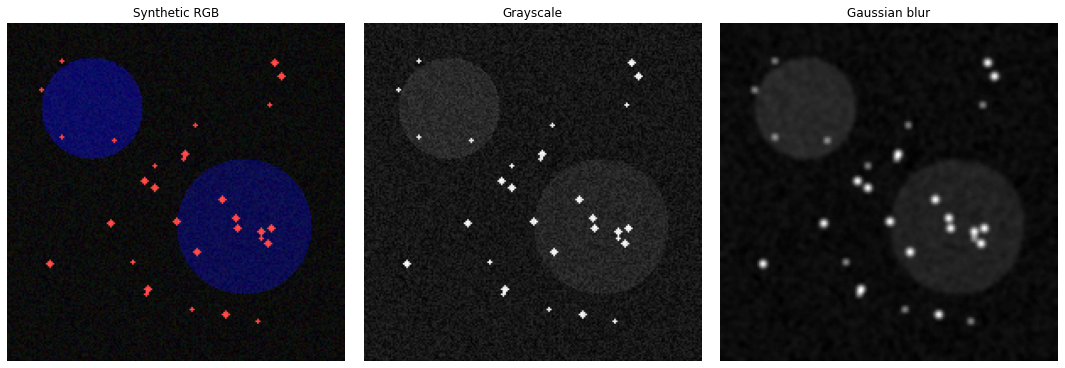

In [7]:
def create_dummy_fish_image(rng, size=200, n_spots=30):
    """
    Synthetic image imitating a FISH experiment: dim blue 'nuclei' (DAPI-like)
    and small bright red 'ecDNA' spots, plus noise.

    Note: this is an idealized simulation. Real microscopy images have more complex
    noise, uneven background and less regular shapes.
    """
    img = np.zeros((size, size, 3), dtype=np.uint8)
    cv2.circle(img, (50, 50), 30, (0, 0, 90), -1)       # nuclei in the blue channel (RGB order)
    cv2.circle(img, (140, 120), 40, (0, 0, 70), -1)
    for _ in range(n_spots):
        x, y = rng.integers(20, size - 20, 2)
        cv2.circle(img, (int(x), int(y)), int(rng.integers(1, 3)), (255, 60, 60), -1)
    noise = rng.integers(0, 25, img.shape, dtype=np.uint8)
    return cv2.add(img, noise)

image_rgb = create_dummy_fish_image(rng)
image_gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

# Gaussian blur: (5, 5) is the kernel size, sigmaX the amount of blur
blurred = cv2.GaussianBlur(image_gray, (5, 5), sigmaX=1.5)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(image_rgb);              axs[0].set_title("Synthetic RGB")
axs[1].imshow(image_gray, cmap="gray"); axs[1].set_title("Grayscale")
axs[2].imshow(blurred, cmap="gray");    axs[2].set_title("Gaussian blur")
for ax in axs: ax.axis("off")
plt.tight_layout(); plt.show()

#### A synthetic image where we know the truth

Next we build a grayscale image of Gaussian spots whose **exact positions we know**. Having this *ground truth* lets us measure how well each method works (Part 6).

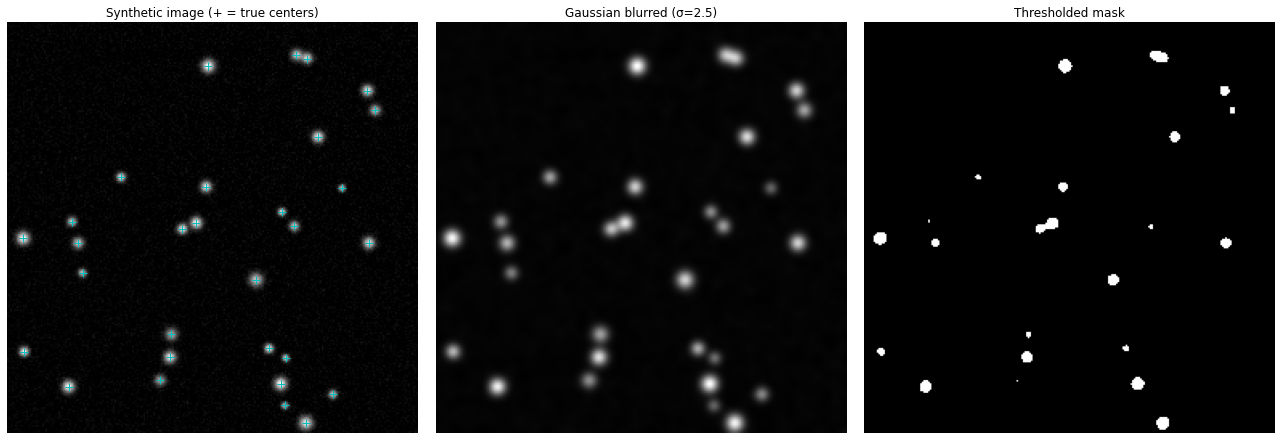

In [8]:
def make_spots(rng, size=256, n_spots=30, sigma_range=(1.5, 3.0), amp_range=(0.6, 1.0),
               noise=0.1, background=0.0, min_dist=6):
    """
    Grayscale image of Gaussian spots (a PSF model) + optional smooth background + noise.
    Returns (image in [0, 1] as float, ground-truth centers as an (N, 2) array of (row, col)).
    """
    centers = []
    while len(centers) < n_spots:                       # keep spots at least `min_dist` apart
        c = rng.uniform(4, size - 4, 2)
        if all(np.hypot(*(c - p)) >= min_dist for p in centers):
            centers.append(c)
    centers = np.array(centers).reshape(-1, 2)
    yy, xx = np.mgrid[:size, :size]
    img = np.zeros((size, size))
    for (cy, cx) in centers:
        s = rng.uniform(*sigma_range); a = rng.uniform(*amp_range)
        img += a * np.exp(-((yy - cy)**2 + (xx - cx)**2) / (2 * s**2))
    if background:
        img += background * (0.5 + 0.5 * np.sin(xx / 30) * np.cos(yy / 20))
    img += noise * rng.standard_normal((size, size))
    return np.clip(img, 0, 1), centers

image_synth_f, gt_centers = make_spots(rng, noise=0.03)
image_synth = img_as_ubyte(image_synth_f)

# --- Gaussian blur + threshold as a baseline detector ---
blurred_image = gaussian(image_synth, sigma=2.5)      # returns float in [0, 1]
threshold = 0.3                                       # this value may need tuning
binary_mask = blurred_image > threshold

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(image_synth, cmap='gray')
axes[0].plot(gt_centers[:, 1], gt_centers[:, 0], 'c+', ms=8); axes[0].set_title('Synthetic image (+ = true centers)')
axes[1].imshow(blurred_image, cmap='gray'); axes[1].set_title('Gaussian blurred (σ=2.5)')
axes[2].imshow(binary_mask, cmap='gray');   axes[2].set_title('Thresholded mask')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

### 2.4 Mask Overlay (RGB + Mask → Masked RGB)
Often in microscopy, we want to visualize our detection results (a binary **mask**) on top of the original color image. This helps us confirm if our algorithm is working correctly.

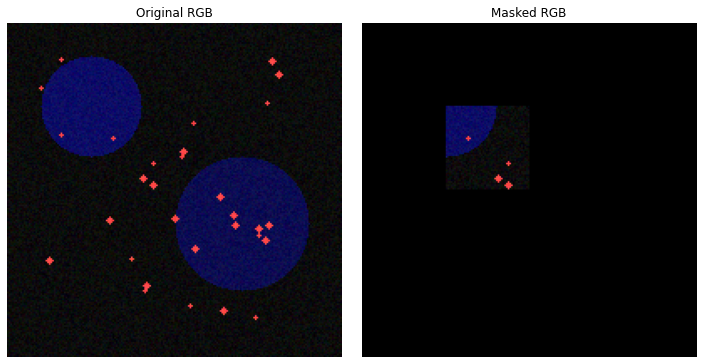

In [9]:
# Suppose 'mask' is a binary image (0 for background, 1 for object)
# Let's create a fake square mask for this demo.
mask = np.zeros_like(image_gray, dtype=bool)
mask[50:100, 50:100] = True

# Create an overlay: keep the original RGB pixels only where the mask is True
masked_rgb = image_rgb.copy()
# We use NumPy's boolean indexing here. Where the mask is False, set pixel to black.
masked_rgb[~mask] = (0, 0, 0)

# Show side by side
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(image_rgb)
axs[0].set_title("Original RGB")
axs[0].axis("off")

axs[1].imshow(masked_rgb)
axs[1].set_title("Masked RGB")
axs[1].axis("off")

plt.tight_layout()
plt.show()

## Part 3: Background Removal & Morphological Operations

### 3.1 The Challenge of Background in Microscopy
In real fluorescence images, the background is rarely a uniform black. Autofluorescence, uneven illumination, or camera sensor noise can create a hazy, uneven glow. This makes faint spots (like ecDNA) much harder to detect.

If we simply threshold the raw image, we might accidentally classify parts of the bright background as objects.

### 3.2 Rolling Ball Algorithm (Background Subtraction)

The **rolling ball** algorithm is a classic and highly effective way to remove uneven background:

1. Imagine a 3D surface plot of your image's intensity values.
2. Now, imagine rolling a ball of a specified radius *underneath* this surface.
3. The ball is too large to fit into the small, sharp peaks (your objects), but it will trace the larger, low-frequency variations of the background.
4. The path traced by the top of this ball is your estimated background. Subtracting it from the original image removes the uneven glow and enhances the contrast of your objects.

> 📌 **Key Parameter**: The **ball radius** should be larger than the largest object you want to keep.

### 3.3 Morphological Operations

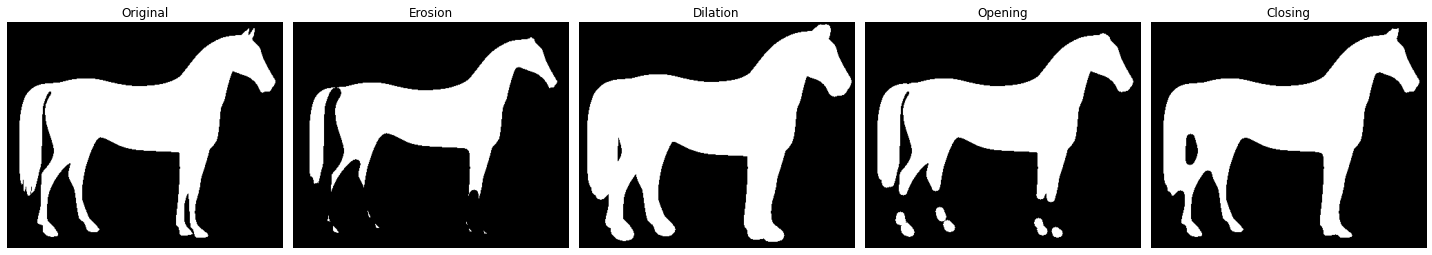

In [10]:
# Basic binary morphology on a built-in binary image (scikit-image's 'horse' silhouette)
from skimage import data
shape = ~data.horse()                 # True = object
se = disk(6)                          # structuring element
ops = {"Original": shape, "Erosion": erosion(shape, se), "Dilation": dilation(shape, se),
       "Opening": opening(shape, se), "Closing": closing(shape, se)}
fig, axs = plt.subplots(1, 5, figsize=(20, 4))
for ax, (name, im) in zip(axs, ops.items()):
    ax.imshow(im, cmap="gray"); ax.set_title(name); ax.axis("off")
plt.tight_layout(); plt.show()

After background subtraction and thresholding, the resulting binary mask can still be noisy. **Morphological operations** are nonlinear filters that modify the shape of objects in a binary image, helping to clean it up.

- **Erosion**: Shrinks white regions, effectively removing thin connections and tiny, isolated noise pixels.
- **Dilation**: Expands white regions, useful for filling small holes or gaps within objects.
- **Opening**: An erosion followed by a dilation. Excellent for removing "salt" noise (small white specks).
- **Closing**: A dilation followed by an erosion. Excellent for filling "pepper" noise (small black holes in objects).

### 3.4 Code Demo: Rolling Ball & Morphology
OpenCV has no built-in rolling-ball function. A closely related and very common alternative is the **white top-hat**: the image minus its morphological *opening* with a flat disk. The rolling ball uses a ball (a curved 3D shape) instead of a flat disk, so the two are not identical, but both remove structures larger than the chosen radius while keeping small bright spots.

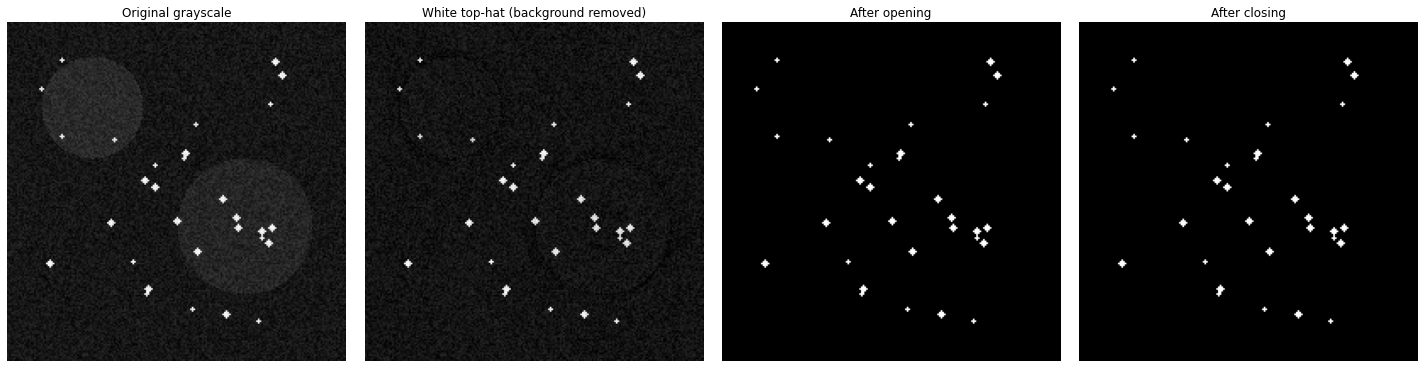

In [11]:
# --- Background removal with a white top-hat (disk radius larger than the spots) ---
radius = 15
background_removed = white_tophat(image_gray, disk(radius))

# --- Threshold + morphology ---
_, binary = cv2.threshold(background_removed, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))   # elliptical kernel suits round objects
opened = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)   # remove small specks
closed = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel, iterations=1)  # fill small holes

fig, axs = plt.subplots(1, 4, figsize=(20, 5))
for ax, im, t in zip(axs, [image_gray, background_removed, opened, closed],
                     ["Original grayscale", "White top-hat (background removed)", "After opening", "After closing"]):
    ax.imshow(im, cmap="gray"); ax.set_title(t); ax.axis("off")
plt.tight_layout(); plt.show()

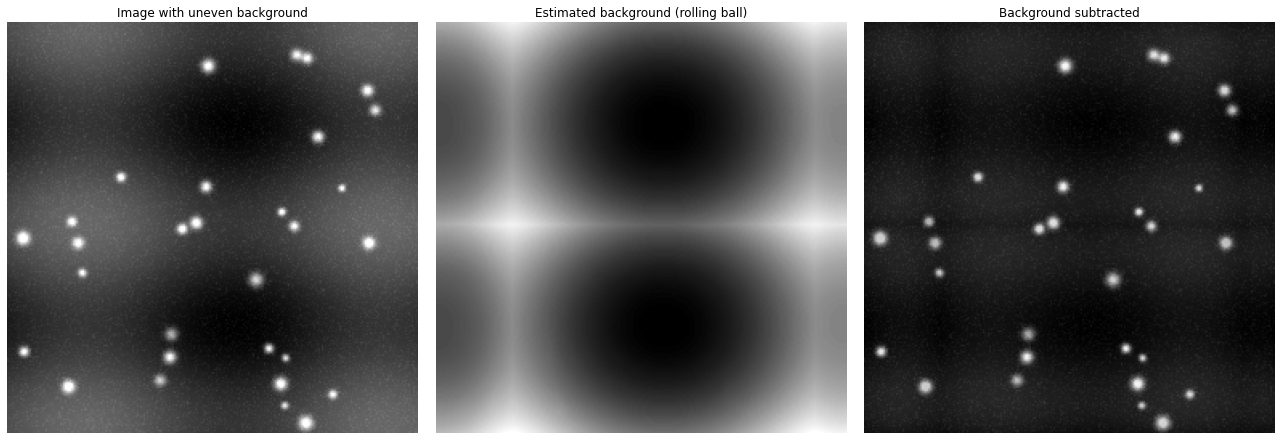

In [12]:
# --- Rolling ball on an image with uneven background ---
yy, xx = np.mgrid[:256, :256]
uneven_background = 0.1 * np.sin(xx / 30) + 0.1 * np.cos(yy / 20) + 0.2
image_with_bg = img_as_ubyte(np.clip(image_synth_f + uneven_background, 0, 1))

background = rolling_ball(image_with_bg, radius=50)     # radius larger than the largest spot
image_subtracted = (image_with_bg.astype(np.int16) - background).clip(0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, im, t in zip(axes, [image_with_bg, background, image_subtracted],
                     ["Image with uneven background", "Estimated background (rolling ball)", "Background subtracted"]):
    ax.imshow(im, cmap="gray"); ax.set_title(t); ax.axis("off")
plt.tight_layout(); plt.show()

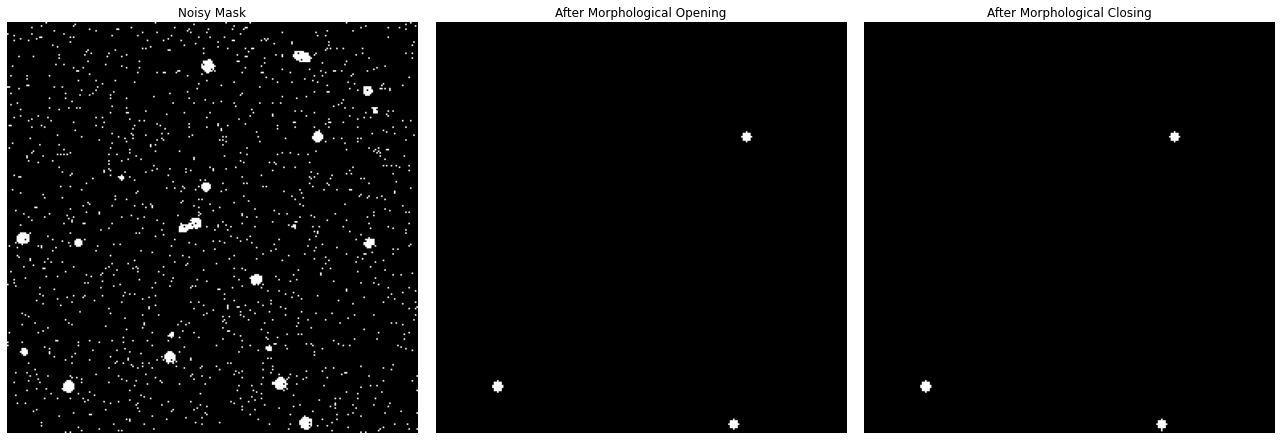

In [13]:
# Add random 'salt' and 'pepper' noise to the synthetic mask, then clean it
noisy_mask = binary_mask.copy()
# Add "salt" noise (white pixels)
salt = rng.random(noisy_mask.shape) > 0.98
noisy_mask[salt] = 1
# Add "pepper" noise (black holes in objects)
pepper = rng.random(noisy_mask.shape) > 0.95
noisy_mask[pepper & binary_mask] = 0

# --- Apply Morphological Opening to remove noise ---
# The 'disk(3)' is called a structuring element; its size determines
# the size of features to be removed.
cleaned_mask_opening = opening(noisy_mask, disk(3))

# --- Apply Morphological Closing to fill holes ---
cleaned_mask_closing = closing(cleaned_mask_opening, disk(3))


# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
ax = axes.ravel()

ax[0].imshow(noisy_mask, cmap='gray')
ax[0].set_title('Noisy Mask')
ax[0].axis('off')

ax[1].imshow(cleaned_mask_opening, cmap='gray')
ax[1].set_title('After Morphological Opening')
ax[1].axis('off')

ax[2].imshow(cleaned_mask_closing, cmap='gray')
ax[2].set_title('After Morphological Closing')
ax[2].axis('off')

plt.tight_layout()
plt.show()

## Part 4: Classical Object Detection Methods

### 4.1 Thresholding & Binarization
Thresholding is the simplest method to segment an image into foreground and background.

- **Global Threshold**: A single intensity cutoff is used for the entire image (e.g., all pixels > 128).
- **Otsu's Method**: Automatically finds an optimal global threshold by maximizing the variance between the foreground and background pixel distributions. It's very common for fluorescence images.
- **Adaptive Threshold**: Calculates a threshold for smaller regions of the image. It's useful for images with varying illumination, but can be sensitive to noise.

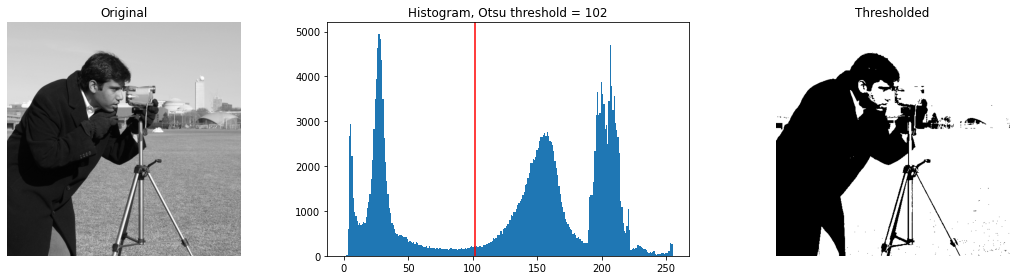

In [14]:
# Histogram thresholding with Otsu's method on a classic test image
camera = data.camera()
t = threshold_otsu(camera)
fig, axs = plt.subplots(1, 3, figsize=(16, 4))
axs[0].imshow(camera, cmap="gray"); axs[0].set_title("Original"); axs[0].axis("off")
axs[1].hist(camera.ravel(), bins=256); axs[1].axvline(t, color="r"); axs[1].set_title(f"Histogram, Otsu threshold = {t}")
axs[2].imshow(camera > t, cmap="gray"); axs[2].set_title("Thresholded"); axs[2].axis("off")
plt.tight_layout(); plt.show()

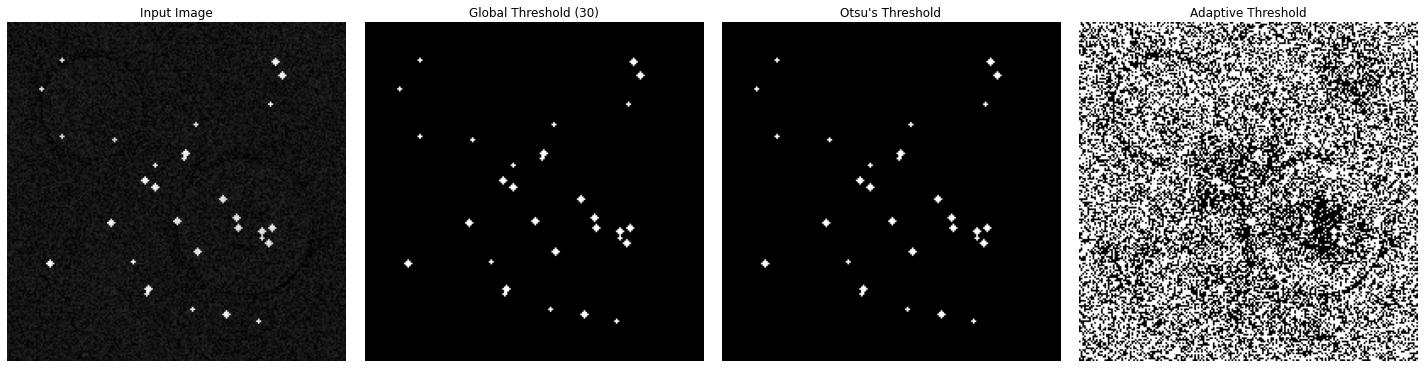

In [15]:
# Using the background-removed image for better results
img_to_thresh = background_removed

# Global threshold (fixed value)
_, binary_global = cv2.threshold(img_to_thresh, 30, 255, cv2.THRESH_BINARY)

# Otsu's threshold
_, binary_otsu = cv2.threshold(img_to_thresh, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Adaptive threshold
# blockSize must be odd. C is a constant subtracted from the mean.
binary_adapt = cv2.adaptiveThreshold(img_to_thresh, 255, cv2.ADAPTIVE_THRESH_MEAN_C, 
                                     cv2.THRESH_BINARY, blockSize=35, C=2)

# Show results
fig, axs = plt.subplots(1, 4, figsize=(20, 5))
axs[0].imshow(img_to_thresh, cmap="gray"); axs[0].set_title("Input Image"); axs[0].axis("off")
axs[1].imshow(binary_global, cmap="gray"); axs[1].set_title("Global Threshold (30)"); axs[1].axis("off")
axs[2].imshow(binary_otsu, cmap="gray"); axs[2].set_title("Otsu's Threshold"); axs[2].axis("off")
axs[3].imshow(binary_adapt, cmap="gray"); axs[3].set_title("Adaptive Threshold"); axs[3].axis("off")

plt.tight_layout()
plt.show()

### 4.2 Connected Components Analysis

Once we have a binary mask (Otsu's is often a good choice), we need to identify each distinct white region as a separate object. **Connected component labeling** does exactly this: it scans the image and assigns a unique ID number to each connected cluster of pixels.

After labeling, we can count the objects and measure properties for each one, such as its area, centroid (center point), and bounding box. This is crucial for quantitative analysis like counting ecDNA foci.

Detected 27 objects initially
Detected 17 objects after size filtering


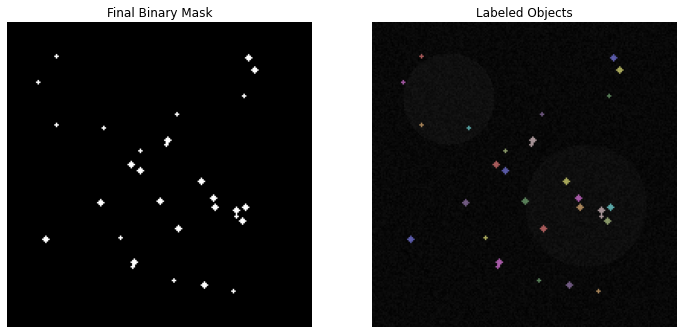

In [16]:
from skimage import measure

# Use the cleaned mask from the morphology step for best results
final_mask = closed

# Label connected regions. connectivity=2 means we consider diagonal pixels as connected (8-connectivity).
labels = measure.label(final_mask, connectivity=2, background=0)
props = measure.regionprops(labels)

print(f"Detected {len(props)} objects initially")

# It's common to filter objects by size to remove remaining noise or large artifacts
min_area = 5
max_area = 200
filtered_props = [p for p in props if min_area < p.area < max_area]

print(f"Detected {len(filtered_props)} objects after size filtering")

# Visualize the labeled objects with random colors
from skimage.color import label2rgb
colored_labels = label2rgb(labels, image=image_gray, bg_label=0)

fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(final_mask, cmap='gray')
axs[0].set_title('Final Binary Mask')
axs[0].axis('off')

axs[1].imshow(colored_labels)
axs[1].set_title('Labeled Objects')
axs[1].axis('off')

plt.show()

Connected components count: 29
Example object stats (first up to 5):
 1. area=98, centroid=(20.9, 183.4)
 2. area=69, centroid=(26.9, 124.9)
 3. area=49, centroid=(42.2, 224.0)
 4. area=31, centroid=(54.5, 228.8)
 5. area=48, centroid=(71.0, 193.2)


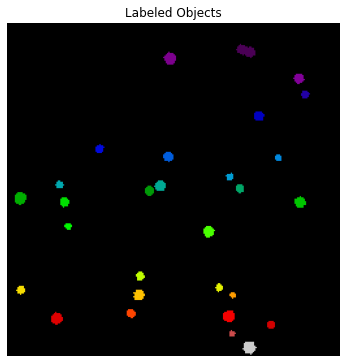

In [17]:
# Quick recap: Otsu + connected components on background-subtracted image
_, bin_otsu = cv2.threshold(image_subtracted, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
from skimage import measure
labels = measure.label(bin_otsu > 0, connectivity=2)
props = measure.regionprops(labels)

print(f"Connected components count: {len(props)}")
if len(props):
    print("Example object stats (first up to 5):")
    for i, p in enumerate(props[:5]):
        print(f" {i+1}. area={int(p.area)}, centroid={tuple(round(float(v), 1) for v in p.centroid)}")

plt.figure(figsize=(6,6))
plt.imshow(labels, cmap='nipy_spectral'); plt.title('Labeled Objects'); plt.axis('off'); plt.show()

### 4.3 Laplacian of Gaussian (LoG) for Blob Detection

Thresholding can fail if objects vary greatly in brightness or are very close to the background intensity. The **Laplacian of Gaussian (LoG)** filter is a more robust method specifically designed to find blobs.

1. It first smooths the image with a **Gaussian** filter (to set the scale and reduce noise).
2. It then applies a **Laplacian** filter (a 2nd derivative operator) which produces a strong response at the center of intensity peaks (blobs).
3. By applying LoG filters at different scales (i.e., different Gaussian sigmas), it can detect blobs of various sizes.

> 📌 **Advantage**: Detects blobs based on their shape and scale, not just their absolute brightness.

Detected 27 blobs


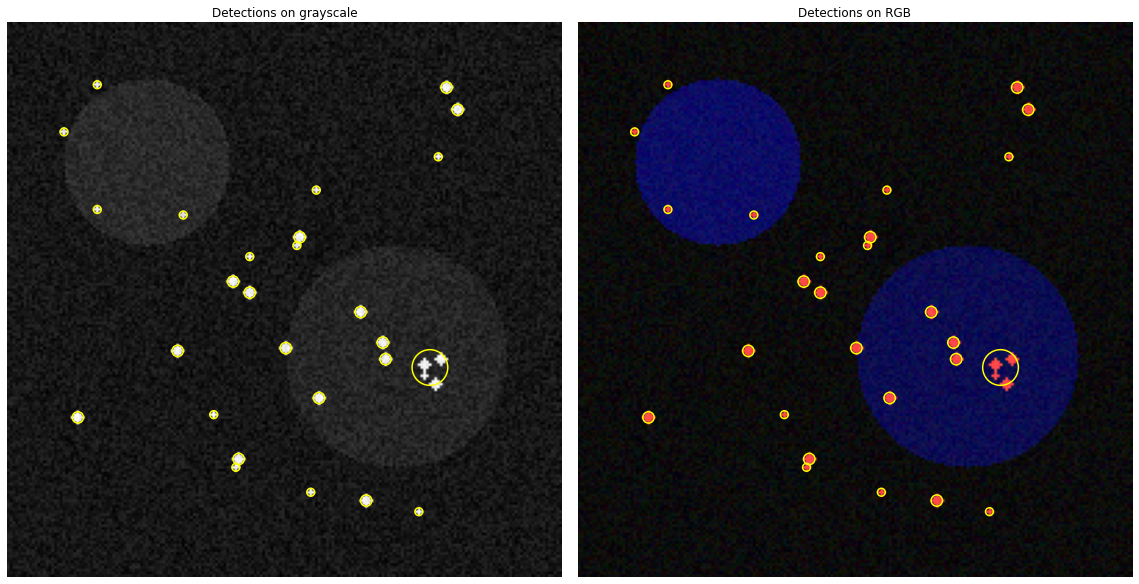

In [18]:
# LoG on the top-hat image of the synthetic RGB example
blobs = blob_log(background_removed, min_sigma=1, max_sigma=5, threshold=0.05)
blobs[:, 2] = blobs[:, 2] * np.sqrt(2)       # in 2D, blob radius ≈ sqrt(2) * sigma
print(f"Detected {len(blobs)} blobs")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, im, t in [(axes[0], image_gray, "Detections on grayscale"), (axes[1], image_rgb, "Detections on RGB")]:
    ax.imshow(im, cmap="gray" if im.ndim == 2 else None); ax.set_title(t); ax.set_axis_off()
    for yb, xb, rb in blobs:
        ax.add_patch(mpatches.Circle((xb, yb), rb, color="yellow", fill=False, linewidth=1.5))
plt.tight_layout(); plt.show()

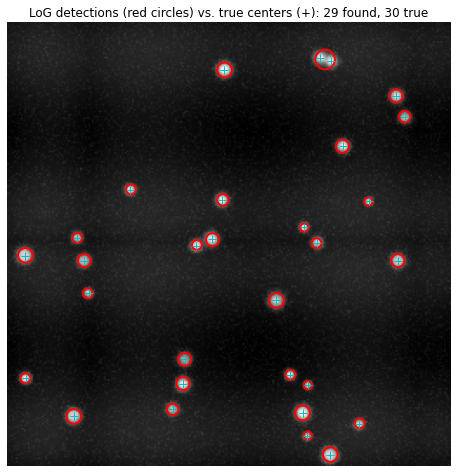

In [19]:
# LoG on the background-subtracted synthetic image, where we know the true centers
blobs = blob_log(image_subtracted, min_sigma=1, max_sigma=4, threshold=0.1)
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(image_subtracted, cmap='gray')
for yb, xb, sb in blobs:
    ax.add_patch(plt.Circle((xb, yb), sb * np.sqrt(2), color='red', linewidth=2, fill=False))
ax.plot(gt_centers[:, 1], gt_centers[:, 0], 'c+', ms=8)
ax.set_title(f'LoG detections (red circles) vs. true centers (+): {len(blobs)} found, {len(gt_centers)} true')
ax.axis('off'); plt.show()

### 4.4 Watershed Segmentation

A common challenge is when objects touch or overlap. Standard thresholding and connected components will merge them into a single blob. The **watershed algorithm** is designed to split these touching objects.

1. It treats the image as a topographic map, where intensity is height.
2. We provide "markers" or "seeds" that are confidently inside each unique object.
3. The algorithm then "floods" the landscape from these markers. The lines where the floods from different markers meet become the boundaries that separate the objects.

Getting the markers right is the most critical and difficult part of using watershed.

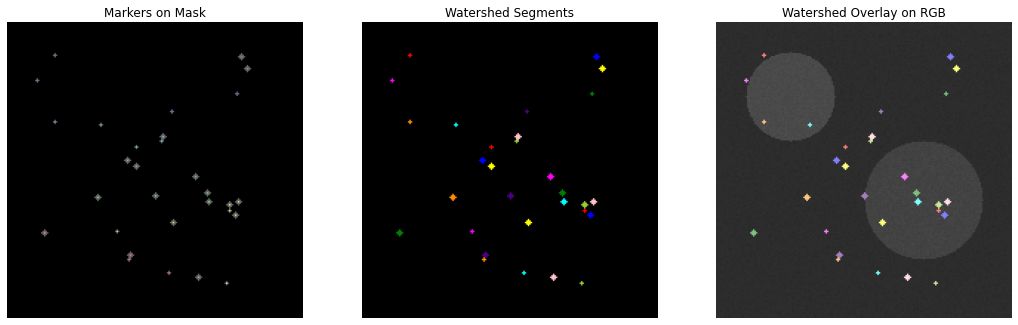

In [20]:
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from skimage import measure
from scipy import ndimage as ndi
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import label2rgb


# To use watershed, we need a good way to find markers for our objects.
# One common method is to use the distance transform.

# 1. Calculate the distance from every foreground pixel to the nearest background pixel
distance = ndi.distance_transform_edt(final_mask)

# 2. Find coordinates of local maxima in the distance map. These are good markers for object centers.
coords = peak_local_max(
    distance,
    footprint=np.ones((5, 5)),   
    labels=final_mask            # restrict to foreground
)

# 3. Create a boolean mask from those coordinates
local_maxi = np.zeros_like(distance, dtype=bool)
local_maxi[tuple(coords.T)] = True

# 4. Label the markers
markers = measure.label(local_maxi)

# 5. Apply the watershed algorithm
labels_ws = watershed(-distance, markers, mask=final_mask)

# --- Enhanced Visualization with RGB Overlay ---
# Create an image where each watershed region is colored differently
# We can overlay this on the original RGB image for context.
image_label_overlay = label2rgb(labels_ws, image=image_rgb, bg_label=0, image_alpha=0.7, alpha=0.5)

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Markers on the binary mask
axs[0].imshow(final_mask, cmap='gray')
axs[0].imshow(markers, cmap='nipy_spectral', alpha=0.6)
axs[0].set_title('Markers on Mask')
axs[0].axis('off')

# Plot 2: Watershed segmentation with distinct colors
axs[1].imshow(label2rgb(labels_ws, bg_label=0))
axs[1].set_title('Watershed Segments')
axs[1].axis('off')

# Plot 3: The final, intuitive overlay on the original image
axs[2].imshow(image_label_overlay)
axs[2].set_title('Watershed Overlay on RGB')
axs[2].axis('off')

plt.show()

## Part 5: Deep Learning for Bioimage Analysis

### 5.1 Why Deep Learning?

Classical methods work well but often have limitations:
- They require careful **parameter tuning** for each new dataset.
- They struggle with noisy, low-contrast, or highly variable images.
- They rely on strong assumptions about object shape (e.g., LoG assumes round blobs).

**Deep Learning (DL)** offers a powerful alternative by **learning** the optimal features and logic directly from annotated data, making models more robust and generalizable.

**Why use Deep Learning?**
* **Robustness**: Well-trained models are often more robust to variations in imaging conditions (brightness, noise, background) than classical methods.
* **Performance**: For complex segmentation tasks (e.g., identifying individual cells in a dense tissue), deep learning models like Cellpose and StarDist significantly outperform classical algorithms like Watershed.
* **No Manual Feature Design**: The network learns the important features, saving you the effort of designing a complex pipeline of filters and morphological operations.

The main drawback is the need for high-quality **annotated data** (i.e., images where an expert has manually outlined the objects of interest) for training.

### 5.2 From Machine Learning → Deep Learning

- **Traditional Machine Learning (ML)**: Requires you to manually engineer features (e.g., object size, intensity, texture) and feed them to a classifier (like a Random Forest or SVM).
- **Deep Learning (DL)**: Automatically learns the most relevant features directly from the raw pixel data. **Convolutional Neural Networks (CNNs)** are the backbone of modern deep learning for image analysis.

### 5.3 CNN Basics
A CNN is a neural network built from several types of layers:

1. **Convolutional Layer**: Applies a set of *trainable* filters to the image. Instead of a fixed Gaussian or Sobel filter, the network learns the best filter shapes to detect relevant patterns (edges, textures, blobs).
2. **Activation Function (e.g., ReLU)**: Introduces non-linearity, allowing the network to learn more complex patterns.
3. **Pooling Layer**: Downsamples the image, making the learned features more robust to small shifts in position and reducing computational complexity.
4. **Fully Connected Layers**: Combine the extracted features at the end of the network to make a final decision (e.g., classification).

For an excellent visual introduction to CNN layers, see the Stanford [CS231n notes on convolutional networks](https://cs231n.github.io/convolutional-networks/).

### 5.4 A Simple CNN Example (Classification of Patches)

Here is a small CNN in PyTorch that could be trained to classify 28×28 image patches as "ecDNA" or "background". We won't train this one; instead we pass a random batch through it to check the shapes. We train a segmentation network (U-Net) further below.

In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
torch.manual_seed(SEED)
print("PyTorch", torch.__version__, "| CUDA available:", torch.cuda.is_available())

PyTorch 2.14.0+cu130 | CUDA available: False


In [22]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)   # 1 input channel -> 16 feature maps
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)                     # 28x28 input -> 7x7 after two poolings
        self.fc2 = nn.Linear(128, 2)                              # 2 classes: ecDNA vs background

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), 2)   # conv -> ReLU -> pool
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = x.flatten(1)                             # flatten feature maps
        x = F.relu(self.fc1(x))
        return self.fc2(x)                           # logits

cnn = SimpleCNN()
dummy = torch.randn(4, 1, 28, 28)                     # a batch of 4 fake patches
print("Output shape:", tuple(cnn(dummy).shape), "-> one score per class for each patch")
print("Trainable parameters:", sum(p.numel() for p in cnn.parameters()))

Output shape: (4, 2) -> one score per class for each patch
Trainable parameters: 205890


### 5.5 U-Net Architecture

For the original architecture diagram, see Figure 1 of [Ronneberger et al. (2015), arXiv:1505.04597](https://arxiv.org/abs/1505.04597).

While a simple CNN can classify patches, we often need to perform **segmentation**—labeling every single pixel in an image. The **UNet** architecture (Ronneberger et al., 2015) became the standard baseline for biomedical image segmentation.

It consists of two main paths:

1.  **Encoder (Contracting Path)**: A series of convolutions and pooling layers that act like a feature extractor. It learns *what* is in the image at different scales.
2.  **Decoder (Expanding Path)**: A series of up-sampling layers that reconstruct a full-resolution segmentation mask from the extracted features. It learns *where* the features are located.
3.  **Skip Connections**: The key innovation of UNet. These connections pass feature maps directly from the encoder to the corresponding decoder layer, allowing the network to use both high-level semantic information (from deep layers) and fine-grained spatial details (from early layers) to create a precise segmentation map.

In [23]:
class UNet(nn.Module):
    """A compact U-Net: 3 resolution levels. `base` sets the width (number of filters)."""
    def __init__(self, n_channels=1, n_classes=1, base=64):
        super().__init__()
        self.enc1 = self.conv_block(n_channels, base)
        self.enc2 = self.conv_block(base, base * 2)
        self.enc3 = self.conv_block(base * 2, base * 4)
        self.up1  = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.dec1 = self.conv_block(base * 4, base * 2)
        self.up2  = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.dec2 = self.conv_block(base * 2, base)
        self.out_conv = nn.Conv2d(base, n_classes, 1)

    @staticmethod
    def conv_block(in_c, out_c):
        return nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(inplace=True))

    def forward(self, x):
        e1 = self.enc1(x)                                   # full resolution
        e2 = self.enc2(F.max_pool2d(e1, 2))                 # 1/2
        e3 = self.enc3(F.max_pool2d(e2, 2))                 # 1/4 (bottleneck)
        d1 = self.dec1(torch.cat([self.up1(e3), e2], 1))    # up to 1/2 + skip connection
        d2 = self.dec2(torch.cat([self.up2(d1), e1], 1))    # up to full + skip connection
        return self.out_conv(d2)                            # one logit per pixel

x_demo = torch.randn(1, 1, 64, 64)
print("Input :", tuple(x_demo.shape))
print("Output:", tuple(UNet(base=16)(x_demo).shape), "-> a prediction for every pixel")

Input : (1, 1, 64, 64)
Output: (1, 1, 64, 64) -> a prediction for every pixel


**Why UNet works well in microscopy:** 
- It trains well from relatively **small** annotated datasets (especially with augmentation), gives sharp boundaries, and handles objects at multiple scales.
- **skip connections** bring back fine details lost in downsampling.  
- When your classical baseline struggles, a trained UNet often helps.

## Part 6: Evaluation Metrics in Image Analysis

### 6.1 Why Metrics Matter

To objectively compare different algorithms (e.g., LoG vs. UNet), we need quantitative **metrics**. These metrics measure the performance of a detection or segmentation algorithm against a **ground truth** (an expert-annotated result).

- **Pixel-level metrics** (Dice, IoU) measure the overlap of segmentation masks.
- **Object-level metrics** (Precision, Recall) measure how many individual objects were correctly detected.
- **Loss functions** are related but different: they are differentiable quantities minimized *during training* (e.g., a soft Dice loss), not evaluation scores.

### 6.2 The Confusion Matrix
At its core, evaluation is about counting four outcomes:

- **True Positive (TP)**: The algorithm correctly detected a real object.
- **False Positive (FP)**: The algorithm detected an object that wasn't there (a hallucination).
- **False Negative (FN)**: The algorithm missed a real object.
- **True Negative (TN)**: The algorithm correctly identified background. (For *object* detection TN is usually undefined, since there is no countable set of "non-objects", which is why precision and recall are preferred.)

### 6.3 Key Metrics

**Precision** (Positive Predictive Value):
$$ \text{Precision} = \frac{TP}{TP + FP} $$
*Of all the detections made, what fraction was correct?* High precision means few false positives.

**Recall** (Sensitivity):
$$ \text{Recall} = \frac{TP}{TP + FN} $$
*Of all the real objects, what fraction did we find?* High recall means few missed objects.

**F1 Score**:
$$ F1 = \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}} $$
The harmonic mean of precision and recall. A single number that balances the trade-off between them.

**Dice Coefficient** (for segmentation masks):
$$ \text{Dice} = \frac{2 \cdot |A \cap B|}{|A| + |B|} $$
Measures the overlap between the ground truth mask (A) and the predicted mask (B). It is equivalent to the F1 score at the pixel level.

**Intersection over Union (IoU)** / Jaccard Index:
$$ \text{IoU} = \frac{|A \cap B|}{|A \cup B|} $$
Another overlap measure, very widely used. IoU is never larger than Dice (they are equal only at 0 or 1), and the two are linked by Dice = 2·IoU / (1 + IoU).

### 6.4 Code Example: Comparing Masks (Dice & IoU)

In [24]:
def dice_coefficient(y_true, y_pred):
    # Ensure boolean arrays
    y_true = y_true.astype(bool)
    y_pred = y_pred.astype(bool)
    intersection = np.logical_and(y_true, y_pred).sum()
    total = y_true.sum() + y_pred.sum()
    return (2. * intersection) / (total + 1e-8)

def iou(y_true, y_pred):
    # Ensure boolean arrays
    y_true = y_true.astype(bool)
    y_pred = y_pred.astype(bool)
    intersection = np.logical_and(y_true, y_pred).sum()
    union = np.logical_or(y_true, y_pred).sum()
    return intersection / (union + 1e-8)

# Example binary masks
y_true = np.array([[0, 1, 1, 0],
                   [0, 1, 1, 0],
                   [0, 0, 0, 0],
                   [0, 0, 0, 0]], dtype=bool)

y_pred = np.array([[0, 1, 0, 0],
                   [0, 1, 1, 0],
                   [0, 0, 1, 0],
                   [0, 0, 0, 0]], dtype=bool)

print(f"Dice Coefficient: {dice_coefficient(y_true, y_pred):.4f}")
print(f"IoU (Jaccard): {iou(y_true, y_pred):.4f}")

Dice Coefficient: 0.7500
IoU (Jaccard): 0.6000


### 6.5 Object-level evaluation: are the *spots* right?

For counting ecDNA, what matters is whether each **spot** was found, not the exact pixels. We match each detection to at most one true spot, and only if they are within a distance tolerance (here 3 pixels). The matching uses the Hungarian algorithm, so each true spot can be claimed only once:

- matched detections → **TP**
- unmatched detections → **FP**
- unmatched true spots → **FN**

In [25]:
def match_points(pred, gt, tol=3.0):
    """One-to-one matching of predicted and true (row, col) points within `tol` pixels.
    Returns TP, FP, FN, precision, recall, F1."""
    pred, gt = np.asarray(pred).reshape(-1, 2), np.asarray(gt).reshape(-1, 2)
    if len(pred) == 0 or len(gt) == 0:
        tp = 0
    else:
        d = np.linalg.norm(pred[:, None, :] - gt[None, :, :], axis=2)
        r, c = linear_sum_assignment(d)
        tp = int((d[r, c] <= tol).sum())
    fp, fn = len(pred) - tp, len(gt) - tp
    p = tp / (tp + fp) if tp + fp else 0.0
    rc = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * p * rc / (p + rc) if p + rc else 0.0
    return dict(TP=tp, FP=fp, FN=fn, precision=p, recall=rc, F1=f1)

# Score the LoG detections from Part 4 against the known centers
print(match_points(blobs[:, :2], gt_centers))

{'TP': 28, 'FP': 1, 'FN': 2, 'precision': 0.9655172413793104, 'recall': 0.9333333333333333, 'F1': 0.9491525423728815}


## Part 6B: Train a Small U-Net and Compare It with LoG

Now we put everything together. We will:

1. **Generate training data**: synthetic 64×64 patches with random spots, uneven background and noise. The target mask is a small disk at each true spot center.
2. **Train** a small U-Net on the CPU for a few minutes.
3. **Evaluate** U-Net and LoG on *new* synthetic test images at three noise levels, using the object-level metrics above.

To keep the comparison fair, LoG's threshold is **tuned** on separate validation images (the value giving the best F1), just as the U-Net learns from training images. We also show an *optimistic* version of LoG whose threshold is re-tuned for each noise level, which you rarely can do in practice because you don't know the noise level in advance. (Background removal is not needed here: the LoG filter already ignores slowly varying background. Try adding a top-hat step and check!)

> ⚠️ Synthetic data is a teaching tool. It lets us know the ground truth exactly, but a model trained on it is **not** ready for real FISH images. For real data you need expert annotations, as in Goble et al. (2025).

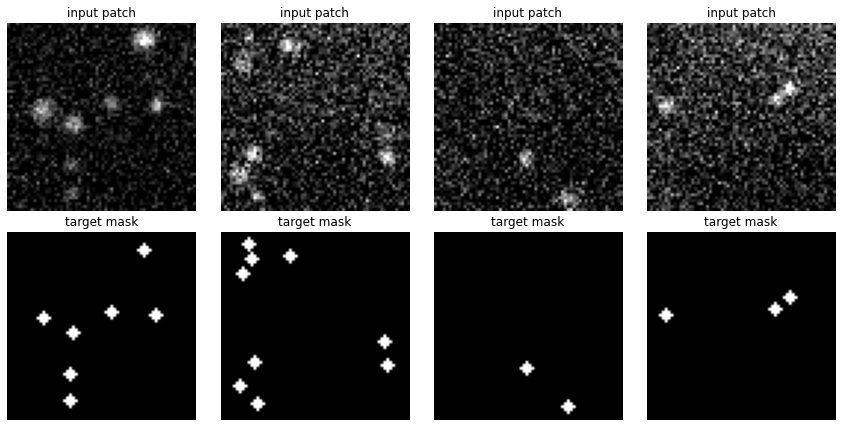

In [26]:
def sample_image(rng, size, noise):
    """Random synthetic image with uneven background, at a given noise level."""
    n = int(rng.integers(0, max(2, size * size // 400)))
    img, centers = make_spots(rng, size=size, n_spots=n, sigma_range=(1.2, 2.5), amp_range=(0.3, 1.0),
                              noise=noise, background=rng.uniform(0, 0.3), min_dist=5)
    return img.astype(np.float32), centers

def centers_to_mask(centers, size, radius=2):
    m = np.zeros((size, size), np.float32)
    for cy, cx in centers:
        cv2.circle(m, (int(round(cx)), int(round(cy))), radius, 1.0, -1)
    return m

def make_batch(rng, batch=16, size=64):
    xs, ys = [], []
    for _ in range(batch):
        img, c = sample_image(rng, size, noise=rng.uniform(0.02, 0.25))
        xs.append(img); ys.append(centers_to_mask(c, size))
    return torch.from_numpy(np.stack(xs)[:, None]), torch.from_numpy(np.stack(ys)[:, None])

xb, yb = make_batch(np.random.default_rng(1), batch=4)
fig, axs = plt.subplots(2, 4, figsize=(12, 6))
for k in range(4):
    axs[0, k].imshow(xb[k, 0], cmap="gray"); axs[0, k].set_title("input patch")
    axs[1, k].imshow(yb[k, 0], cmap="gray"); axs[1, k].set_title("target mask")
for ax in axs.ravel(): ax.axis("off")
plt.tight_layout(); plt.show()

step  100/600  loss 1.203  (17s)


step  200/600  loss 0.619  (33s)


step  300/600  loss 0.269  (49s)


step  400/600  loss 0.223  (67s)


step  500/600  loss 0.204  (83s)


step  600/600  loss 0.196  (99s)


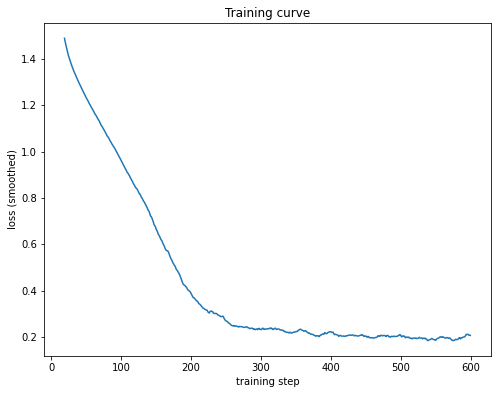

In [27]:
import time
torch.manual_seed(SEED)
train_rng = np.random.default_rng(SEED + 1)

model = UNet(n_channels=1, n_classes=1, base=16)
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)
pos_weight = torch.tensor([5.0])                  # spots are rare pixels: weight them more

def loss_fn(logits, target):
    bce = F.binary_cross_entropy_with_logits(logits, target, pos_weight=pos_weight)
    prob = torch.sigmoid(logits)
    soft_dice = 1 - (2 * (prob * target).sum() + 1) / (prob.sum() + target.sum() + 1)
    return bce + soft_dice

n_steps, losses = 600, []
t0 = time.time()
model.train()
for step in range(n_steps):
    x, y = make_batch(train_rng)
    optimizer.zero_grad()
    loss = loss_fn(model(x), y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    if (step + 1) % 100 == 0:
        print(f"step {step+1:4d}/{n_steps}  loss {np.mean(losses[-100:]):.3f}  ({time.time()-t0:.0f}s)")

plt.plot(pd.Series(losses).rolling(20).mean())
plt.xlabel("training step"); plt.ylabel("loss (smoothed)"); plt.title("Training curve"); plt.show()

In [28]:
@torch.no_grad()
def unet_detect(img, thr=0.5):
    """Run the U-Net on a whole image and return spot centers (row, col)."""
    model.eval()
    prob = torch.sigmoid(model(torch.from_numpy(img[None, None].astype(np.float32))))[0, 0].numpy()
    lab = measure.label(prob > thr)
    return np.array([p.centroid for p in measure.regionprops(lab)]).reshape(-1, 2), prob

def log_detect(img, thr):
    b = blob_log(img, min_sigma=1, max_sigma=3, num_sigma=5, threshold=thr)
    return b[:, :2]

# --- Tune LoG's threshold on validation images (fair comparison) ---
grid = [0.02, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
def tune_log(val_set):
    f1 = {t: float(np.mean([match_points(log_detect(im, t), c)["F1"] for im, c in val_set])) for t in grid}
    return max(f1, key=f1.get), f1

val_rng = np.random.default_rng(SEED + 2)
val_set = [sample_image(val_rng, 128, noise=val_rng.uniform(0.02, 0.25)) for _ in range(10)]
best_thr, f1 = tune_log(val_set)
print("LoG validation F1 by threshold:", {k: round(v, 2) for k, v in f1.items()})
print("One threshold for all images:", best_thr)

noise_levels = {"low": 0.05, "medium": 0.15, "high": 0.25}
thr_per_noise = {name: tune_log([sample_image(val_rng, 128, nz) for _ in range(10)])[0]
                 for name, nz in noise_levels.items()}
print("Thresholds re-tuned for each noise level:", thr_per_noise)

# --- Test on new images at three noise levels ---
test_rng = np.random.default_rng(SEED + 3)
rows = []
for noise_name, noise in noise_levels.items():
    for _ in range(10):
        img, gt = sample_image(test_rng, 256, noise)
        for method, pred in [("LoG (one threshold)", log_detect(img, best_thr)),
                             ("LoG (tuned per noise level)", log_detect(img, thr_per_noise[noise_name])),
                             ("U-Net", unet_detect(img)[0])]:
            rows.append(dict(noise=noise_name, method=method, **match_points(pred, gt)))
res = pd.DataFrame(rows)

# Pool TP/FP/FN over the 10 test images per condition, then compute metrics
summary = res.groupby(["noise", "method"], sort=False)[["TP", "FP", "FN"]].sum()
summary["precision"] = summary.TP / (summary.TP + summary.FP)
summary["recall"]    = summary.TP / (summary.TP + summary.FN)
summary["F1"]        = 2 * summary.precision * summary.recall / (summary.precision + summary.recall)
summary.round(3)

LoG validation F1 by threshold: {0.02: 0.06, 0.05: 0.15, 0.1: 0.38, 0.15: 0.69, 0.2: 0.77, 0.25: 0.8, 0.3: 0.68, 0.4: 0.38, 0.5: 0.0}
One threshold for all images: 0.25


Thresholds re-tuned for each noise level: {'low': 0.1, 'medium': 0.2, 'high': 0.3}


TP   FP   FN  precision  recall     F1
noise  method                                                              
low    LoG (one threshold)          632    0  363      1.000   0.635  0.777
       LoG (tuned per noise level)  980    0   15      1.000   0.985  0.992
       U-Net                        990    0    5      1.000   0.995  0.997
medium LoG (one threshold)          542    5  306      0.991   0.639  0.777
       LoG (tuned per noise level)  681   98  167      0.874   0.803  0.837
       U-Net                        831   14   17      0.983   0.980  0.982
high   LoG (one threshold)          609  891  229      0.406   0.727  0.521
       LoG (tuned per noise level)  447  138  391      0.764   0.533  0.628
       U-Net                        779   77   59      0.910   0.930  0.920

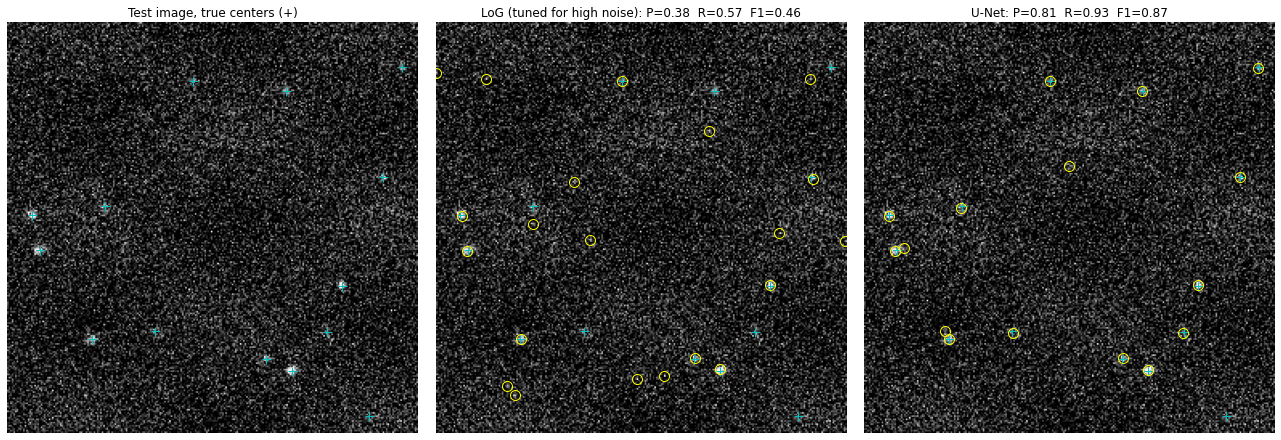

In [29]:
# Visual comparison on one high-noise test image
img, gt = sample_image(np.random.default_rng(42), 256, 0.25)
log_pts = log_detect(img, thr_per_noise['high'])
unet_pts, prob = unet_detect(img)

fig, axs = plt.subplots(1, 3, figsize=(18, 6))
axs[0].imshow(img, cmap="gray"); axs[0].plot(gt[:, 1], gt[:, 0], "c+", ms=9); axs[0].set_title("Test image, true centers (+)")
for ax, pts, name in [(axs[1], log_pts, "LoG (tuned for high noise)"), (axs[2], unet_pts, "U-Net")]:
    m = match_points(pts, gt)
    ax.imshow(img, cmap="gray")
    ax.plot(gt[:, 1], gt[:, 0], "c+", ms=9)
    ax.plot(pts[:, 1], pts[:, 0], "o", mfc="none", mec="yellow", ms=10)
    ax.set_title(f"{name}: P={m['precision']:.2f}  R={m['recall']:.2f}  F1={m['F1']:.2f}")
for ax in axs: ax.axis("off")
plt.tight_layout(); plt.show()

**How to read these results**

- Compare the two LoG rows: how much of LoG's weakness is just **choosing the threshold**?
- Look at how the methods compare as **noise increases**. Where does each one lose precision (extra false spots) or recall (missed spots)?
- The U-Net learned what a spot looks like from examples. LoG applies a fixed mathematical template with one tuned threshold.
- Both were built for *this* synthetic world. A real FISH image differs: spots touch, there are two colors, chromosomes are present, and the noise is different. This is called **domain shift**. Let's see what happens when we apply the synthetic-trained U-Net to our real image anyway.

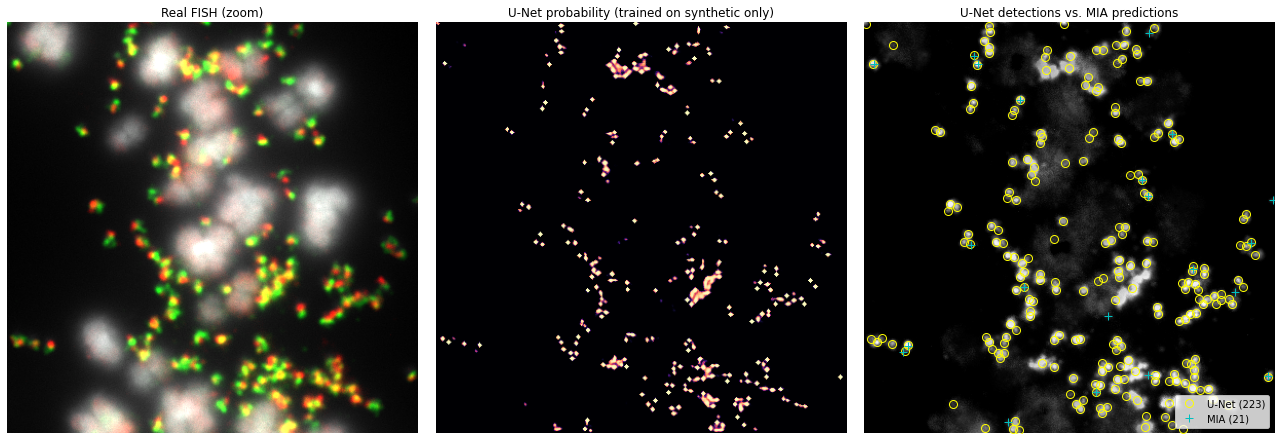

In [30]:
# Apply the synthetic-trained U-Net to the real FISH probe signal (qualitative only!)
ys, xs = slice(700, 1100), slice(1250, 1650)
green_probe = np.clip(rgb_fish[..., 1] - rgb_fish[..., 2], 0, 255).astype(np.uint8)
probe = np.maximum(red_probe, green_probe)[ys, xs].astype(np.float32) / 255.0
mia = io.imread(DATA_DIR / "fish_mia_mask.tif")[ys, xs] > 0

real_pts, real_prob = unet_detect(probe)
mia_pts = np.array([p.centroid for p in measure.regionprops(measure.label(mia))]).reshape(-1, 2)

fig, axs = plt.subplots(1, 3, figsize=(18, 6))
axs[0].imshow(rgb_fish[ys, xs].astype(np.uint8)); axs[0].set_title("Real FISH (zoom)")
axs[1].imshow(real_prob, cmap="magma");            axs[1].set_title("U-Net probability (trained on synthetic only)")
axs[2].imshow(probe, cmap="gray")
axs[2].plot(real_pts[:, 1], real_pts[:, 0], "o", mfc="none", mec="yellow", ms=8, label=f"U-Net ({len(real_pts)})")
axs[2].plot(mia_pts[:, 1], mia_pts[:, 0], "c+", ms=8, label=f"MIA ({len(mia_pts)})")
axs[2].legend(loc="lower right"); axs[2].set_title("U-Net detections vs. MIA predictions")
for ax in axs: ax.axis("off")
plt.tight_layout(); plt.show()

The U-Net has never seen a real FISH image, yet it marks many of the visible spots, and in this window it marks far more than MIA does. Does that make it better? **We cannot tell from this picture.** MIA is itself a model, not ground truth. It may merge clustered ecDNA ("hubs") into single objects, while our U-Net may split clusters or respond to chromosome edges. Disagreement tells us the methods *differ*, not which one is right. Deciding that takes expert-annotated real images, which is exactly what published tools like MIA and ecCount are trained and validated on.

> **Try it:** change `n_steps`, the noise range in `make_batch`, or `base` (network width) and re-run. How do the test metrics change? What happens with only 100 training steps?

## Part 7: Practical Tools & Resources

### 7.1 Why Tools Matter
While writing custom Python code offers maximum flexibility, researchers often rely on established, ready-to-use tools for their workflows, especially those with graphical user interfaces (GUIs) for interactive analysis and curation.

For many common tasks, you don't need to train a model from scratch. Excellent pre-trained tools are available:

* **TrackMate (Fiji/ImageJ plugin)**: A user-friendly tool for detecting and tracking spots. It includes a LoG detector and, since version 7, integrates machine- and deep-learning segmenters such as StarDist, Cellpose, ilastik and Weka. Great for interactive analysis and manual curation.
* **Cellpose**: A generalist, deep-learning-based algorithm for segmenting cells and nuclei. It's incredibly robust across different microscopy types but is not optimized for detecting tiny, sub-resolution spots like ecDNA foci.
* **QuPath**: Open-source software focused on digital pathology and whole-slide image analysis. It has both classical and AI tools for cell detection and tissue classification.
* **RS-FISH (Fiji)**: Precise, scalable spot detection designed specifically for FISH, in 2D and 3D.
* **Custom Python Scripts**: Using libraries like scikit-image, TensorFlow, or PyTorch, you can build and train your own custom models for specialized tasks.

**Comparison: LoG vs. CNN**
* **LoG/DoG**: Fast, requires no training data, but parameters often need to be tuned for each dataset.
* **CNNs (like U-Net)**: Can be highly accurate and robust if trained on a good dataset, but require significant amounts of annotated data and computational resources for training.

**Bottom line for ecDNA detection**: A classical workflow (Gaussian blur → LoG → local maxima) is a strong baseline. For crowded or variable images, a CNN trained on expert-annotated data is the next step, as in the MIA-based pipeline of Goble et al. (2025).

### 7.2 Comparison: Which Tool for Which Task?

| Tool                  | Strengths                                       | Weaknesses                               | Best for...                               |
|-----------------------|-------------------------------------------------|------------------------------------------|-------------------------------------------|
| **TrackMate (Fiji)** | Easy-to-use LoG detector, great GUI, tracking   | Not ideal for large-scale batch processing | Quick analysis of a few FISH images       |
| **u-track (Matlab)** | High-accuracy Gaussian fitting, robust tracking | Requires Matlab license, complex setup     | High-precision particle tracking studies  |
| **Cellpose (Python)** | Generalist DL model, works out-of-the-box       | Poor at detecting small, dot-like objects| Segmenting whole cells and nuclei         |
| **QuPath (Java)** | Excellent for tissue pathology, whole-slide images | Overkill for single-field microscopy     | Digital pathology, tissue analysis        |
| **RS-FISH (Fiji)** | Accurate FISH spot localization, 2D/3D, scales to large data | Spot detection only | Counting FISH spots in large datasets |
| **ImageJ/Fiji** | Huge ecosystem of plugins, scriptable           | GUI can be clunky for batch workflows    | Quick preprocessing, interactive analysis |
| **Python Libraries** | Maximum flexibility, scalability, open-source   | Requires coding expertise                | Building custom research pipelines        |

- **If you want a GUI and quick dot detection on a few images:** try **TrackMate** (ImageJ) with its LoG detector and sub‑pixel refinement.  
- **If you’re tracking particles over time:** **u‑track** (Matlab) is a classic for precise localization and linking.  
- **If you need general cell/nucleus segmentation fast:** **Cellpose** (Python) is excellent—just not ideal for tiny FISH dots.  
- **If you’re doing tissue‑scale pathology:** **QuPath** shines for whole‑slide workflows.  
- **If you want full control and batch pipelines:** Python (`skimage`, `opencv`, PyTorch) lets you build exactly what you need.

## Part 8: Future Directions in Bioimage Analysis

### 8.1 Super-Resolution Microscopy

Conventional fluorescence microscopy is diffraction-limited (~200 nm). Super-resolution techniques like **STORM/PALM** (Single-Molecule Localization Microscopy) and **SIM** (Structured Illumination Microscopy) break this barrier, allowing us to visualize subcellular structures with nanometer precision.

> **Impact for ecDNA**: Allows visualization of ecDNA hubs and their interactions with chromatin at a much finer detail than standard FISH.
> *Reference: Lelek et al., Nature Reviews Methods Primers (2021).*

### 8.2 AI Beyond Supervised Learning

So far, we’ve introduced CNNs and UNet, which need labeled training data. But labeling is costly. Emerging approaches include:

- **Self-Supervised Learning (SSL)**: Models learn the structure of unlabeled images (e.g., by predicting missing pixels).
- **Foundation Models**: Models pretrained on diverse microscopy datasets, fine-tuned for specific tasks (e.g., Segment Anything and its microscopy adaptations).
- **Generative Models (diffusion, GANs)**: For simulating microscopy data or denoising.

> 📌 **Impact for ecDNA**: Future ecDNA detectors may train on massive unlabeled microscopy archives, reducing manual annotation needs.

### 8.3 Multimodal AI in Biology

Recent advances integrate multiple imaging and omics data:

- Microscopy + transcriptomics (**spatial omics**).
- Histology + FISH + clinical metadata.
- **Vision-language foundation models** in pathology, such as **PLIP** (Huang et al., 2023) and **CONCH** (Lu et al., 2024), that align images with text and can be searched or queried in natural language.

> 📌 **Impact for ecDNA**: Detecting not only ecDNA spots, but correlating their presence with gene expression, drug response, and patient survival.

### 8.4 Trends in 2021–2025

- **TrackMate 7** (Ershov et al., *Nature Methods*, 2022): integrates StarDist, Cellpose, ilastik and Weka segmentation into tracking.
- **Cellpose 2.0** (Pachitariu & Stringer, *Nature Methods*, 2022): human-in-the-loop training of custom segmentation models.
- **Imaging ecDNA review** (Purshouse, Pollard & Bickmore, *Histochem Cell Biol*, 2024): ecDNA imaging approaches and their challenges.
- **ecDNA prevalence** (Bailey et al., *Nature*, 2024): ecDNA found in about 17% of tumour samples across 39 tumour types.
- **Segment Anything** (Kirillov et al., 2023): inspired "generalist segmentation" tools for microscopy.

### 8.5 The Big Picture

We are moving toward:

- Faster, more automated pipelines.
- Less human parameter tuning.
- Models that generalize across labs, cell types, and imaging conditions.

> 📌 **For students**: Learning both classical methods (LoG, morphology, rolling ball) and modern DL (UNet, CNNs) prepares you to use the best tool for the problem.

## Part 9: Wrap-Up & Further Exploration

### 9.1 Recap of What We Learned

In this notebook, we built a bridge from classical image analysis to deep learning approaches for biomedical microscopy.

- **Part 1 – Microscopy Basics**: How fluorescence microscopy and FISH work, why ecDNA appears as glowing dots, and why spots look like Gaussian blobs.
- **Part 2 – Gaussian Blur & Masking**: How Gaussian filters reduce noise and why they model the microscope PSF. Learned to apply and overlay masks on images.
- **Part 3 – Rolling Ball & Morphology**: How to remove uneven background and refine masks with erosion, dilation, opening, and closing.
- **Part 4 – Classical Object Detection**: Explored thresholding, connected components, Laplacian of Gaussian, and watershed segmentation.
- **Part 5 – Deep Learning (CNNs & U-Net)**: Learned how CNNs automatically learn filters and how U-Net became the standard for biomedical segmentation.
- **Part 6 – Evaluation Metrics**: Covered Dice, IoU, and object-level Precision, Recall and F1, then **trained a U-Net** and compared it fairly with LoG.
- **Part 7 – Tools & Resources**: Surveyed TrackMate, Cellpose, QuPath, and other key software for image analysis.
- **Part 8 – Future Directions**: Explored super-resolution, self-supervised learning, and multimodal AI in biology.

### 9.2 Why This Journey Matters
Classical methods (Gaussian blur, LoG, rolling ball) teach foundational thinking in image processing. Deep learning models (CNNs, UNet) show how AI can adapt and generalize to complex biological images. Both approaches are valuable — together, they form the toolbox of the modern bioimage analyst.

### 9.3 Next Steps for Students

- Experiment with the provided code cells on your own images.
- Try different thresholds, blur values, and morphological kernels.
- Compare classical vs. DL results using the metrics we've learned.
- Explore the tools mentioned, like TrackMate in Fiji, to see these concepts in action.

### 9.4 GitHub Repository for Hands-On Learning

To go beyond this notebook, you can explore a complete ecDNA detection pipeline that integrates many of these steps — from preprocessing and object detection to machine learning classification.

👉 **GitHub Tutorial Repository:**
[ecDNA Detection Pipeline – Tutorial & Code](https://github.com/Brunk-Lab/ecEnhance)

This repository (MIT License) is also the source of the example FISH image used in these notebooks. It includes:
- Preprocessing (background subtraction, Gaussian blur).
- Classical object detection (LoG, morphology).
- Feature extraction and evaluation scripts.

> 📌 This is the “big picture” application of what we’ve learned — a real-world research pipeline.

### ✅ End of Notebook 3

**Congratulations! You’ve now learned:**
- The physics of microscopy.
- The math & code behind classical detection.
- The architecture of CNNs & U-Net, and how to train one.
- The metrics & tools to evaluate methods.
- The future directions where AI is taking biomedical image analysis.

### References and Further Resources

**Core Scientific References**
1. Lichtman, J.W. & Conchello, J.-A. (2005). **Fluorescence microscopy.** *Nature Methods* 2:910–919.
2. Airy, G.B. (1835). **On the diffraction of an object-glass with circular aperture.** *Trans. Cambridge Philos. Soc.* 5:283–291.
3. Rayleigh, Lord (1896). **On the theory of optical images, with special reference to the microscope.** *Philosophical Magazine* 42:167–195.
4. Zhang, B., Zerubia, J. & Olivo-Marin, J.-C. (2007). **Gaussian approximations of fluorescence microscope point-spread function models.** *Applied Optics* 46:1819–1829.
5. Sternberg, S.R. (1983). **Biomedical image processing.** *Computer* 16:22–34. *(rolling ball)*
6. Lindeberg, T. (1998). **Feature detection with automatic scale selection.** *Int. J. Computer Vision* 30:79–116. *(LoG, scale space)*
7. van der Walt, S. et al. (2014). **scikit-image: image processing in Python.** *PeerJ* 2:e453.
8. LeCun, Y., Bengio, Y. & Hinton, G. (2015). **Deep learning.** *Nature* 521:436–444.
9. Ronneberger, O., Fischer, P. & Brox, T. (2015). **U-Net: convolutional networks for biomedical image segmentation.** *MICCAI 2015*, LNCS 9351:234–241. [arXiv:1505.04597](https://arxiv.org/abs/1505.04597)
10. Lelek, M. et al. (2021). **Single-molecule localization microscopy.** *Nature Reviews Methods Primers* 1:39.
11. Ershov, D. et al. (2022). **TrackMate 7: integrating state-of-the-art segmentation algorithms into tracking pipelines.** *Nature Methods* 19:829–832.
12. Stringer, C. et al. (2021). **Cellpose: a generalist algorithm for cellular segmentation.** *Nature Methods* 18:100–106.
13. Pachitariu, M. & Stringer, C. (2022). **Cellpose 2.0: how to train your own model.** *Nature Methods* 19:1634–1641.
14. Bahry, E. et al. (2022). **RS-FISH: precise, interactive, fast, and scalable FISH spot detection.** *Nature Methods* 19:1563–1567.
15. Kirillov, A. et al. (2023). **Segment Anything.** *ICCV 2023*. [arXiv:2304.02643](https://arxiv.org/abs/2304.02643)
16. Huang, Z. et al. (2023). **A visual–language foundation model for pathology image analysis using medical Twitter.** *Nature Medicine* 29:2307–2316.
17. Lu, M.Y. et al. (2024). **A visual-language foundation model for computational pathology.** *Nature Medicine* 30:863–874.
18. Purshouse, K., Pollard, S.M. & Bickmore, W.A. (2024). **Imaging extrachromosomal DNA (ecDNA) in cancer.** *Histochemistry and Cell Biology* 162:53–64.
19. Bailey, C. et al. (2024). **Origins and impact of extrachromosomal DNA.** *Nature* 635:193–200.
20. Goble, K. et al. (2025). **Leveraging AI to automate detection and quantification of extrachromosomal DNA to decode drug responses.** *Frontiers in Pharmacology* 15:1516621.

**Learning and Training Resources**
- Stanford CS231n: [Convolutional neural networks](https://cs231n.github.io/convolutional-networks/)
- FPbase: [Fluorescent protein & dye spectra](https://www.fpbase.org)
- University of Pennsylvania Microscopy Core: [Online tutorials and courses](https://www.med.upenn.edu/cdbmicroscopycore/online-tutorials-and-courses.html)
- Harvard Image Analysis Collaboratory: [Learning resources](https://iac.hms.harvard.edu/resources/learning.html)
- Data Carpentry: [Image processing with Python](https://datacarpentry.github.io/image-processing/)
- [BioImage Book](https://bioimagebook.github.io/README.html) (Pete Bankhead)
- [BioImage Analysis Notebooks](https://haesleinhuepf.github.io/BioImageAnalysisNotebooks/intro.html) (Robert Haase)
- EMBL-EBI: [Microscopy data analysis, machine learning and the BioImage Archive (course materials)](https://www.ebi.ac.uk/training/materials/microscopy-data-analysis-machine-learning-and-the-bioimage-archive-materials/)

---

### Acknowledgements

This notebook was prepared with the assistance of AI tools (ChatGPT, Grok, Gemini and Claude), which were used to help draft, edit, test and refine the code and explanatory text. Final responsibility for scientific accuracy, structure and educational content rests with the author.

Example FISH data: Brunk Lab, [ecEnhance](https://github.com/Brunk-Lab/ecEnhance) repository (MIT License).